<a href="https://colab.research.google.com/github/abeerahateeq/neurofive-ml-track/blob/main/California_Housing_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

sns.set_style("whitegrid")

housing = fetch_california_housing()
print(housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [5]:
# Convert to DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

# Display the first 5 rows of the DataFrame
display(df.head())

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [6]:
# Display basic information about the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


### Exploring the Target Variable: Median House Value (Price)

Let's examine the distribution of the target variable, which is the median house value, to understand its spread and identify any potential skewness or outliers.

In [7]:
# Rename 'MedHouseVal' to 'Price' for consistency and better readability
df.rename(columns={'MedHouseVal': 'Price'}, inplace=True)

# Display the first 5 rows again to confirm the column name change
display(df.head())

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


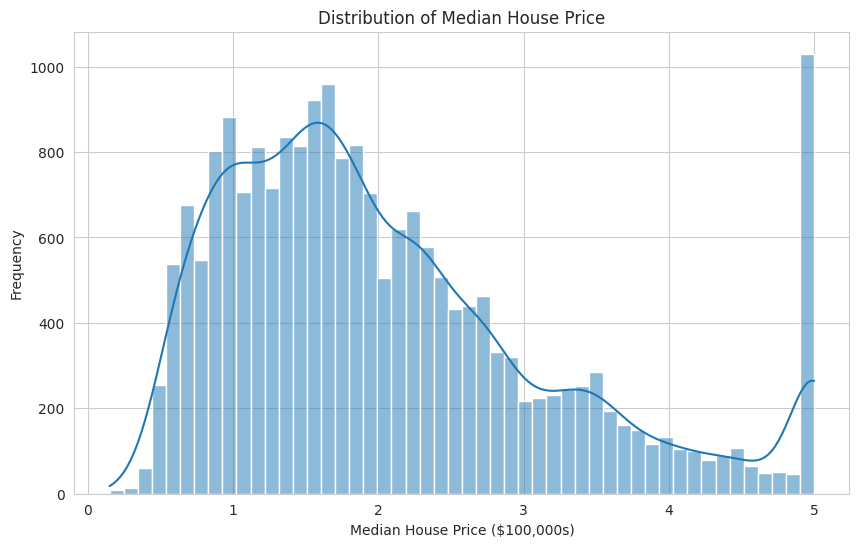

In [8]:
# Plot the distribution of the 'Price' column
plt.figure(figsize=(10, 6))
sns.histplot(df['Price'], bins=50, kde=True)
plt.title('Distribution of Median House Price')
plt.xlabel('Median House Price ($100,000s)')
plt.ylabel('Frequency')
plt.show()

### Exploring Feature Relationships: Correlation Matrix

To understand how different features relate to each other and to the target variable ('Price'), we'll compute and visualize a correlation matrix. This will help identify highly correlated features and potential predictors for the house prices.

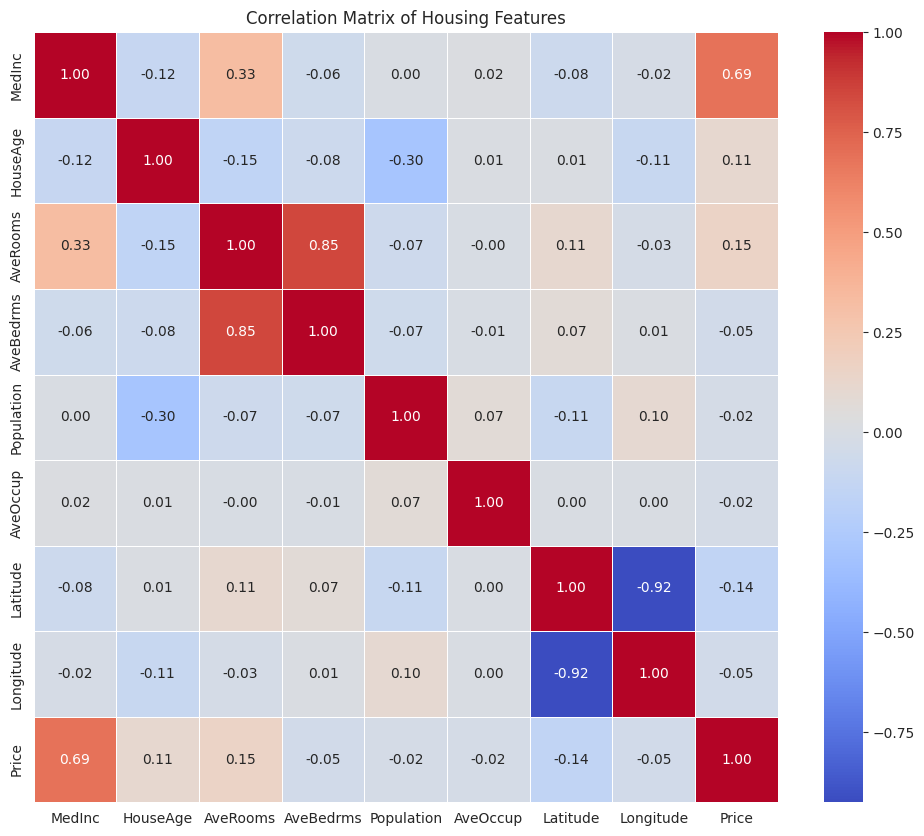

In [9]:
# Calculate the correlation matrix
correlation_matrix = df.corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Housing Features')
plt.show()

### Preparing Data for Modeling

Based on our exploration, we'll now prepare the data for training a machine learning model. This involves defining features (X) and the target variable (y), and then splitting the dataset into training and testing sets to evaluate the model's performance on unseen data.

In [10]:
# Define features (X) and target (y)
X = df.drop('Price', axis=1)
y = df['Price']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 16512 samples
Testing set size: 4128 samples


### Model Training: Linear Regression

We will now train a Linear Regression model on the training data. Linear Regression is a fundamental algorithm for regression tasks that models the linear relationship between features and the target variable.

In [11]:
# Initialize the Linear Regression model
model = LinearRegression()

# Train the model on the training data
model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


### Model Evaluation

After training, it's crucial to evaluate the model's performance on the unseen test data. We'll use two common regression metrics:
- **Mean Squared Error (MSE)**: The average of the squared differences between predicted and actual values. Lower values indicate better fit.
- **R-squared (R2)**: Represents the proportion of the variance in the dependent variable that is predictable from the independent variables. Higher values (closer to 1) indicate a better fit.

In [12]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

Mean Squared Error (MSE): 0.5559
R-squared (R2): 0.5758


In [13]:
display(df.describe())

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


### Feature Selection and Re-training

Based on your input, we will now proceed with a subset of features. This can help in reducing model complexity, preventing overfitting, and potentially improving interpretability. We will redefine our features `X` and then re-split the data, retrain the model, and evaluate it again.

In [14]:
features = [
    "MedInc",
    "HouseAge",
    "AveRooms",
    "AveBedrms",
    "Population"
]

X = df[features]
y = df["Price"]

print(f"New features selected: {features}")

# Re-split the data into training and testing sets with the new features
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size (with new features): {X_train.shape[0]} samples")
print(f"Testing set size (with new features): {X_test.shape[0]} samples")

New features selected: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population']
Training set size (with new features): 16512 samples
Testing set size (with new features): 4128 samples


### Re-training the Linear Regression Model

Now we will retrain the Linear Regression model using the data with the selected features.

In [15]:
# Initialize the Linear Regression model again
model_selected_features = LinearRegression()

# Train the model on the training data with selected features
model_selected_features.fit(X_train, y_train)

print("Linear Regression model re-trained successfully with selected features!")

Linear Regression model re-trained successfully with selected features!


### Re-evaluating the Model

Let's evaluate the performance of the re-trained model on the test data with the selected features.

In [16]:
# Make predictions on the test set using the re-trained model
y_pred_selected = model_selected_features.predict(X_test)

# Evaluate the re-trained model
mse_selected = mean_squared_error(y_test, y_pred_selected)
r2_selected = r2_score(y_test, y_pred_selected)

print(f"Mean Squared Error (MSE) with selected features: {mse_selected:.4f}")
print(f"R-squared (R2) with selected features: {r2_selected:.4f}")

Mean Squared Error (MSE) with selected features: 0.6434
R-squared (R2) with selected features: 0.5090


### Calculate Root Mean Squared Error (RMSE) and R-squared

Let's calculate the RMSE, which is the square root of the MSE, to get an error metric in the same units as the target variable (Price). We will also reconfirm the R-squared score.

In [17]:
rmse_selected = np.sqrt(mean_squared_error(y_test, y_pred_selected))
r2_selected_confirm = r2_score(y_test, y_pred_selected)

print(f"RMSE with selected features: {rmse_selected:.3f}")
print(f"R² Score with selected features: {r2_selected_confirm:.3f}")

RMSE with selected features: 0.802
R² Score with selected features: 0.509
